# Multi-Armed Bandits

In this notebook we study different action selection policies for the classical **multi-armed bandit problem**.

A bandit problem consists of K possible actions (arms).  
Each arm produces a stochastic reward according to an unknown probability distribution.

The goal of the agent is to **maximize the cumulative reward** by balancing:

• Exploration → trying new actions  
• Exploitation → choosing the best action discovered so far

We study the following policies:

- ε-greedy
- Optimistic Greedy
- UCB
- Thompson Sampling
- Gradient Bandit

Performance metrics:

• Mean reward  
• Mean cumulative reward  
• Percentage of optimal action selection

## IMPORTS

In [22]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(12345)

## BANDIT ENVIRONMENT

In [23]:
class BernoulliBanditEnv:

    def __init__(self, p, reward_scale=1):
        self.p = np.array(p)
        self.k = len(p)
        self.reward_scale = reward_scale
        self.best_action = np.argmax(p)

    def reward(self, action):
        return self.reward_scale * np.random.binomial(1, self.p[action])

## AGENTS

### $\epsilon$-greedy / UCB / Thompson

In [24]:
class Agent:

    def __init__(self, learning_rule, decision_rule, param=None, label=None):

        self.learning_rule = learning_rule
        self.decision_rule = decision_rule
        self.param = param if param else {}
        self.label = label if label else decision_rule

        self.epsilon = self.param.get("epsilon",0.1)
        self.c = self.param.get("UCB_param",2)

    def environment(self, env):

        self.env = env
        self.k = env.k

        self.iteration = 0
        self.q_estimate = np.zeros(self.k)
        self.act_count = np.zeros(self.k)

        if self.learning_rule == "BayesianBetaPrior":
            self.alpha = np.ones(self.k)
            self.beta = np.ones(self.k)

    def act(self):

        self.iteration += 1

        if self.decision_rule == "greedy":
            return np.argmax(self.q_estimate)

        elif self.decision_rule == "epsilon-greedy":

            if np.random.rand() < self.epsilon:
                return np.random.randint(self.k)

            return np.argmax(self.q_estimate)

        elif self.decision_rule == "UCB":

            untried = np.where(self.act_count==0)[0]

            if len(untried)>0:
                return np.random.choice(untried)

            bonus = self.c * np.sqrt(np.log(self.iteration)/self.act_count)

            return np.argmax(self.q_estimate + bonus)

        elif self.decision_rule == "Thompson":

            samples = np.random.beta(self.alpha,self.beta)

            return np.argmax(samples)

    def learn(self,a,r):

        self.act_count[a]+=1

        if self.learning_rule == "averaging":

            self.q_estimate[a]+= (r-self.q_estimate[a])/self.act_count[a]

        elif self.learning_rule == "BayesianBetaPrior":

            self.alpha[a]+=r
            self.beta[a]+=1-r

### Optimistic Greedy

In [25]:
class OptimisticGreedyAgent:

    def __init__(self,Q0,label=None):

        self.Q0 = Q0
        self.label = label if label else f"Optimistic Q0={Q0}"

    def environment(self,env):

        self.env = env
        self.k = env.k
        self.iteration = 0

        self.q_estimate = np.ones(self.k)*self.Q0
        self.act_count = np.zeros(self.k)

    def act(self):

        self.iteration+=1

        return np.argmax(self.q_estimate)

    def learn(self,a,r):

        self.act_count[a]+=1

        self.q_estimate[a]+= (r-self.q_estimate[a])/self.act_count[a]

### Gradient Bandit

In [26]:
class GradientAgent:

    def __init__(self,alpha0,baseline_type="none",label=None):

        self.alpha0 = alpha0
        self.baseline_type = baseline_type
        self.label = label if label else f"Gradient α={alpha0}"

    def environment(self,env):

        self.env = env
        self.k = env.k
        self.iteration = 0

        self.H = np.zeros(self.k)

        if self.baseline_type=="const":
            self.baseline = env.reward_scale*np.max(env.p)
        else:
            self.baseline = 0

    def act(self):

        self.iteration+=1

        expH = np.exp(self.H - np.max(self.H))
        self.pi = expH/np.sum(expH)

        return np.random.choice(self.k,p=self.pi)

    def learn(self,a,r):

        alpha = self.alpha0/self.iteration

        advantage = r-self.baseline

        self.H -= alpha*advantage*self.pi
        self.H[a]+= alpha*advantage

## SIMULATE FUNCTION

In [27]:
def simulate(agents,p,n_steps=1000,n_reps=2000,reward_scale=1):

    rewards_mean = np.zeros((len(agents),n_steps))
    best_mean = np.zeros((len(agents),n_steps))

    for i,agent in enumerate(agents):

        run_rewards = np.zeros((n_reps,n_steps))
        run_best = np.zeros((n_reps,n_steps))

        for r in range(n_reps):

            env = BernoulliBanditEnv(p,reward_scale)

            agent.environment(env)

            for t in range(n_steps):

                a = agent.act()

                reward = env.reward(a)

                agent.learn(a,reward)

                run_rewards[r,t]=reward
                run_best[r,t] = 1 if a==env.best_action else 0

        rewards_mean[i]=run_rewards.mean(axis=0)
        best_mean[i]=run_best.mean(axis=0)

    return rewards_mean,best_mean

## PLOTTING FUNCTION

In [28]:
def plot_timeseries(agents,rewards,best,title):

    plt.figure(figsize=(15,4))

    plt.subplot(1,3,1)

    for i,a in enumerate(agents):
        plt.plot(rewards[i],label=a.label)

    plt.title("Mean reward")
    plt.xlabel("Step")
    plt.legend()


    plt.subplot(1,3,2)

    for i,a in enumerate(agents):
        plt.plot(np.cumsum(rewards[i]),label=a.label)

    plt.title("Cumulative reward")
    plt.xlabel("Step")


    plt.subplot(1,3,3)

    for i,a in enumerate(agents):
        plt.plot(100*best[i],label=a.label)

    plt.title("% Optimal action")
    plt.xlabel("Step")

    plt.suptitle(title)

    plt.tight_layout()
    plt.show()

## EXPERIMENT SETUP

In [29]:
p = np.array([0.2,0.2,0.4,0.2,0.2,0.2,0.2,0.8,0.2,0.2])

T = 1000
R = 2000

## BASIC ALGORITHMS

### $\epsilon$-greedy

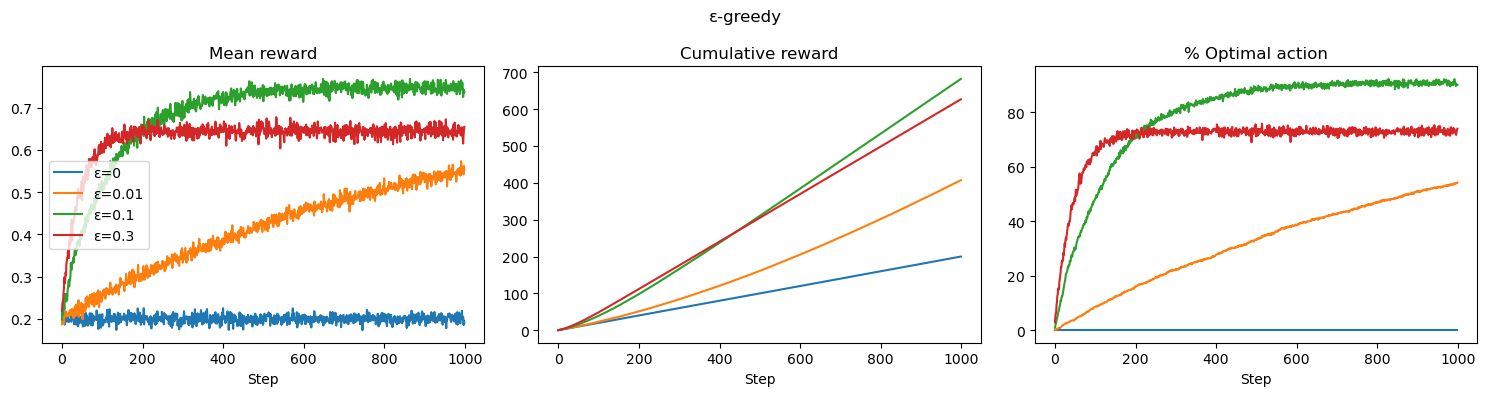

In [30]:
agents = [

    Agent("averaging","epsilon-greedy",{"epsilon":0},"ε=0"),
    Agent("averaging","epsilon-greedy",{"epsilon":0.01},"ε=0.01"),
    Agent("averaging","epsilon-greedy",{"epsilon":0.1},"ε=0.1"),
    Agent("averaging","epsilon-greedy",{"epsilon":0.3},"ε=0.3")

]

rewards,best = simulate(agents,p)

plot_timeseries(agents,rewards,best,"ε-greedy")

### Optimistic Greddy

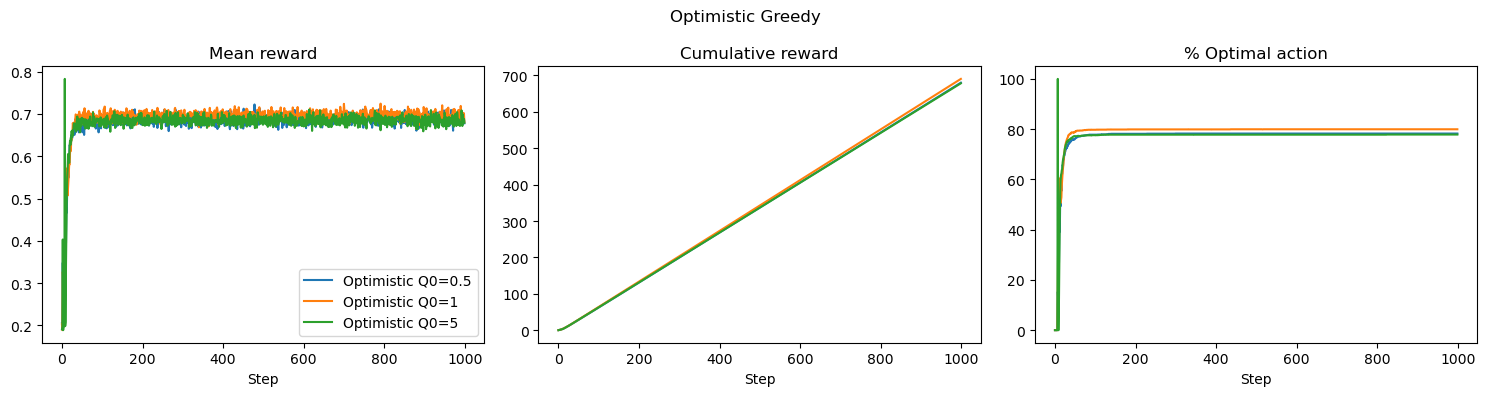

In [31]:
agents = [

    OptimisticGreedyAgent(0.5),
    OptimisticGreedyAgent(1),
    OptimisticGreedyAgent(5)

]

rewards,best = simulate(agents,p)

plot_timeseries(agents,rewards,best,"Optimistic Greedy")

### UCB

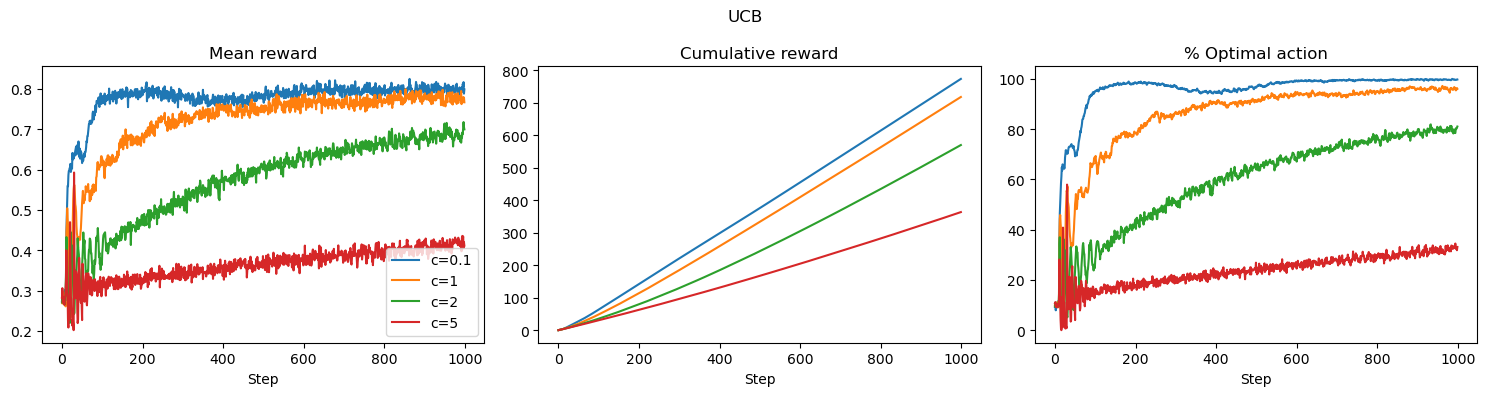

In [32]:
agents = [

    Agent("averaging","UCB",{"UCB_param":0.5},"c=0.1"),
    Agent("averaging","UCB",{"UCB_param":1},"c=1"),
    Agent("averaging","UCB",{"UCB_param":2},"c=2"),
    Agent("averaging","UCB",{"UCB_param":5},"c=5")

]

rewards,best = simulate(agents,p)

plot_timeseries(agents,rewards,best,"UCB")

### Thompson Sampling

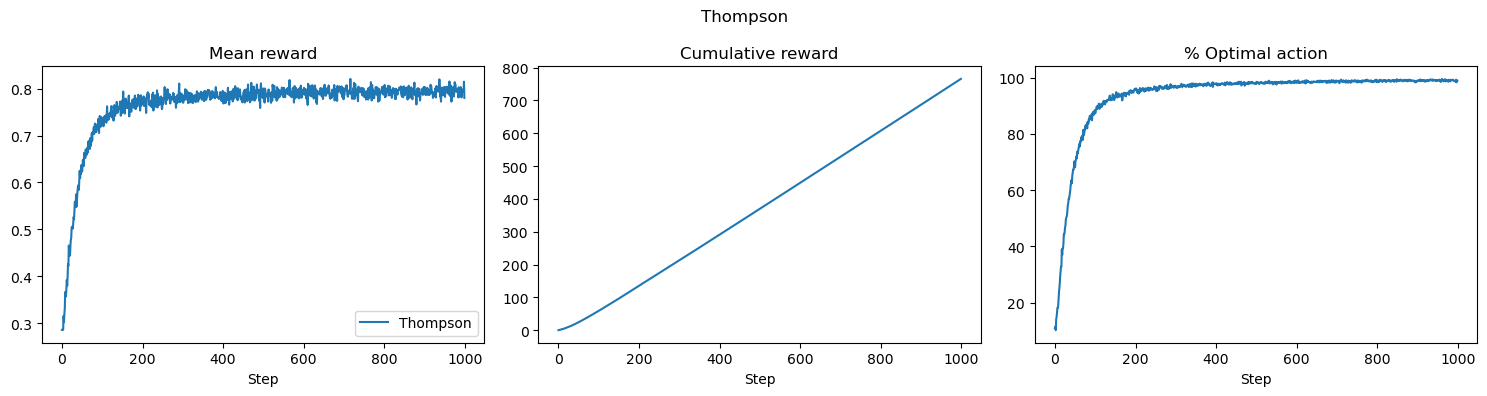

In [33]:
agents = [

    Agent("BayesianBetaPrior","Thompson",label="Thompson")

]

rewards,best = simulate(agents,p)

plot_timeseries(agents,rewards,best,"Thompson")

### Algorithm Comparison

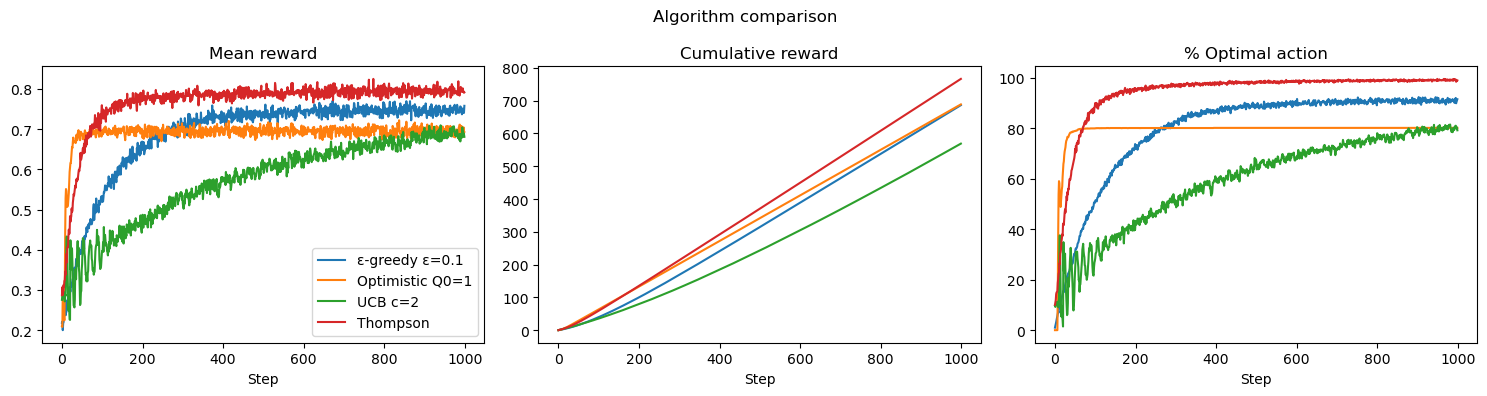

In [34]:
agents = [

Agent("averaging","epsilon-greedy",{"epsilon":0.1},"ε-greedy ε=0.1"),

OptimisticGreedyAgent(1,"Optimistic Q0=1"),

Agent("averaging","UCB",{"UCB_param":2},"UCB c=2"),

Agent("BayesianBetaPrior","Thompson",label="Thompson")

]

rewards, best = simulate(agents,p)

plot_timeseries(agents,rewards,best,"Algorithm comparison")

## GRADIENT METHOD

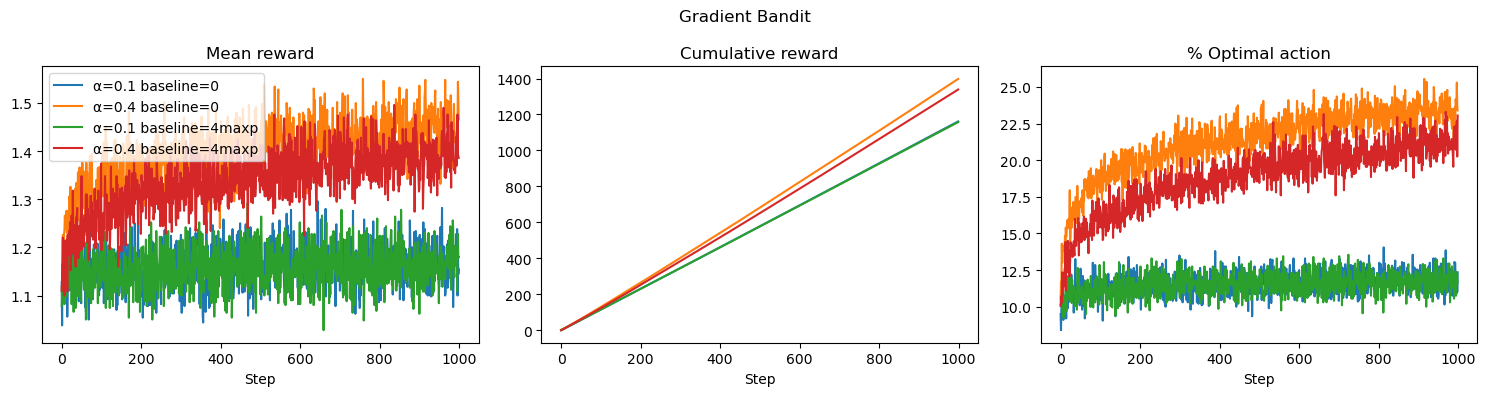

In [35]:
agents = [

GradientAgent(0.1,"none","α=0.1 baseline=0"),
GradientAgent(0.4,"none","α=0.4 baseline=0"),
GradientAgent(0.1,"const","α=0.1 baseline=4maxp"),
GradientAgent(0.4,"const","α=0.4 baseline=4maxp")

]

rewards,best = simulate(agents,p,reward_scale=4)

plot_timeseries(agents,rewards,best,"Gradient Bandit")

## PARAMETER STUDY BY LEARNING CURVE

In [36]:
def learning_curve(make_agent,params,p,reward_scale=1):

    scores=[]

    for param in params:

        agent = make_agent(param)

        rewards,_ = simulate([agent],p,reward_scale=reward_scale)

        scores.append(np.mean(rewards[0]))

    plt.semilogx(params,scores,marker="o")

    plt.xlabel("Parameter")
    plt.ylabel("Average reward")

    plt.show()

### $\epsilon$ learnig curve

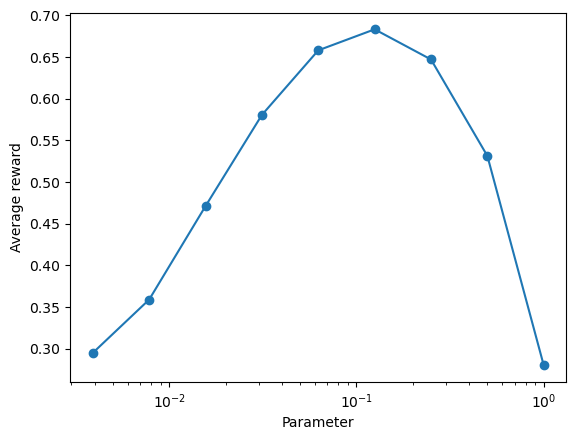

In [37]:
eps_values = 2.0**np.arange(-8,1)

learning_curve(

lambda e: Agent("averaging","epsilon-greedy",{"epsilon":e}),

eps_values,

p

)

### UCB learning curve

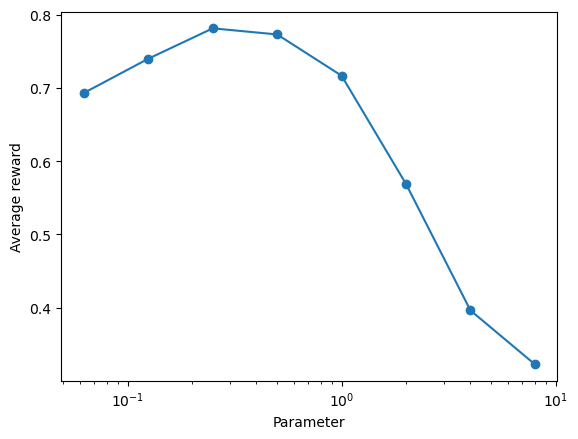

In [38]:
c_values = 2.0**np.arange(-4,4)

learning_curve(

lambda c: Agent("averaging","UCB",{"UCB_param":c}),

c_values,

p

)

### Optimistic Q0

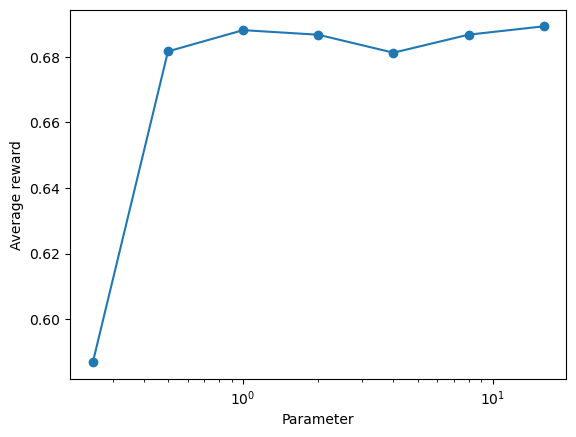

In [39]:
Q0_values = 2.0**np.arange(-2,5)

learning_curve(

lambda q: OptimisticGreedyAgent(q),

Q0_values,

p

)

### Gradient $\alpha$

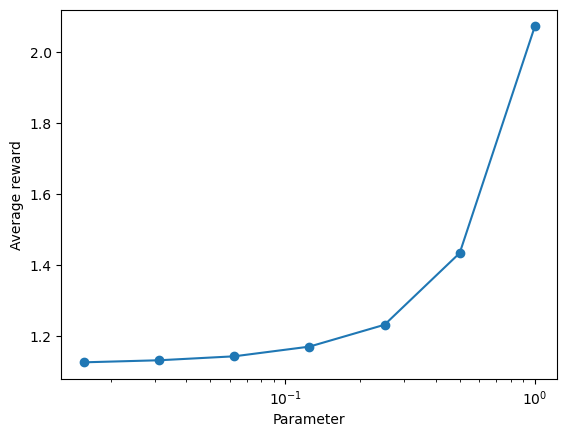

In [40]:
alpha_values = 2.0**np.arange(-6,1)

learning_curve(

lambda a: GradientAgent(a,"const"),

alpha_values,

p,

reward_scale=4

)